In [1]:
import pandas as pd

df = pd.read_csv("arrhythmia.data", header=None)

In [2]:
import numpy as np

df.replace("?", np.nan, inplace=True)   # replacing all ? with NaN values 

In [3]:
# make columns numerical 
df = df.apply(pd.to_numeric)

In [4]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, 0 to 279
dtypes: float64(125), int64(155)
memory usage: 988.9 KB


,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


In [7]:
df.iloc[:, -1].value_counts().sort_index()

# 1 is normal and 2-16 is arrhythmia 

279
1     245
2      44
3      15
4      15
5      13
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64

In [14]:
# renaming the diagnosis column 

df.rename(columns={279: "diagnosis"}, inplace=True)

In [15]:
df["diagnosis"].value_counts()

diagnosis
1     245
10     50
2      44
6      25
16     22
3      15
4      15
5      13
9       9
15      5
14      4
7       3
8       2
Name: count, dtype: int64

In [16]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percent.head(20)

13     83.185841
11      4.867257
10      1.769912
14      0.221239
12      0.221239
3       0.000000
4       0.000000
5       0.000000
264     0.000000
249     0.000000
250     0.000000
251     0.000000
252     0.000000
253     0.000000
254     0.000000
255     0.000000
256     0.000000
257     0.000000
258     0.000000
259     0.000000
dtype: float64

In [17]:
# rename column name from 13 

df.columns = [f"feature_{i}" if i != 279 else "diagnosis" for i in df.columns]

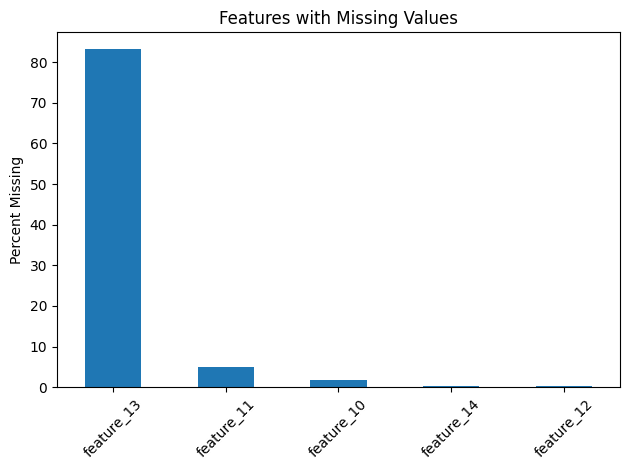

In [19]:
import matplotlib.pyplot as plt

missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)  # missing % 

# Keep only columns with > 0% missing
missing_nonzero = missing_percent[missing_percent > 0]

plt.figure()
missing_nonzero.plot(kind="bar")
plt.ylabel("Percent Missing")
plt.title("Features with Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Completeness

Completeness was assessed by calculating the percentage of missing values for each variable. Missing values were originally represented as “?” placeholders and converted to NaN prior to analysis. Overall, the dataset demonstrates strong completeness across most variables. The majority of ECG derived features contain no missing data.

One variable (Column 13) exhibits substantial missingness (83.2%) and will likely require exclusion from analysis due to insufficient data availability. A small number of additional variables demonstrate minimal missingness (<5%), which may be addressed through imputation or case wise deletion depending on downstream modeling needs.

Importantly, the diagnosis label and demographic variables remain complete, ensuring reliable classification and subgroup comparison.

In [28]:
df.rename(columns={"feature_diagnosis": "diagnosis"}, inplace=True)   # renaming diagnosis column for downstream analysis 

In [29]:
df.columns[-5:]

Index(['feature_275', 'feature_276', 'feature_277', 'feature_278',
       'diagnosis'],
      dtype='object')

In [30]:
df["diagnosis"].value_counts(normalize=True) * 100

diagnosis
1     54.203540
10    11.061947
2      9.734513
6      5.530973
16     4.867257
3      3.318584
4      3.318584
5      2.876106
9      1.991150
15     1.106195
14     0.884956
7      0.663717
8      0.442478
Name: proportion, dtype: float64

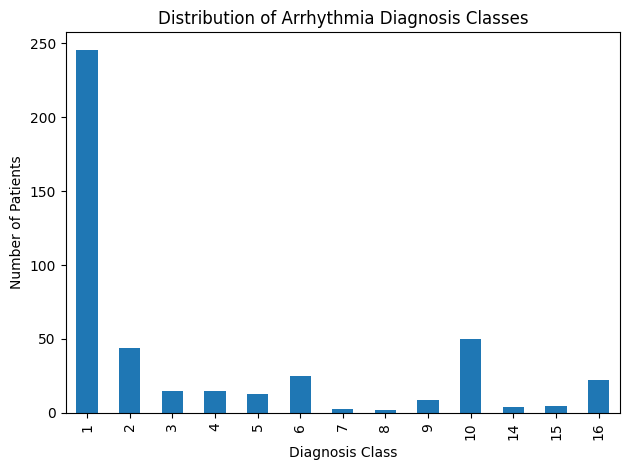

In [31]:
import matplotlib.pyplot as plt

class_dist = df["diagnosis"].value_counts().sort_index()

plt.figure()
class_dist.plot(kind="bar")
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Patients")
plt.title("Distribution of Arrhythmia Diagnosis Classes")
plt.tight_layout()
plt.show()

The diagnosis distribution contains 16 classes representing normal cardiovascular rhythms and various arrhythmia subtypes. Class 1 (normal ECG) constitutes 54.2% of the dataset and represents the majority. The second most frequent arrhythmia class includes Class 10 (11.1%), and Class 2 (9.7%) and the remaining subclasses account for fewer than 5% of observations and a small amount constitute less than 1%. This distribution demonstrates a class imbalance, particularly among rarer arrhythmia subtypes. This imbalance may influence downstream classification and should be considered when interpreting the data set and corresponding results. 


In [32]:
df["feature_0"].describe()   # age 

count    452.000000
mean      46.471239
std       16.466631
min        0.000000
25%       36.000000
50%       47.000000
75%       58.000000
max       83.000000
Name: feature_0, dtype: float64

In [33]:
df["feature_1"].value_counts(normalize=True) * 100   # sex 

feature_1
1    55.088496
0    44.911504
Name: proportion, dtype: float64

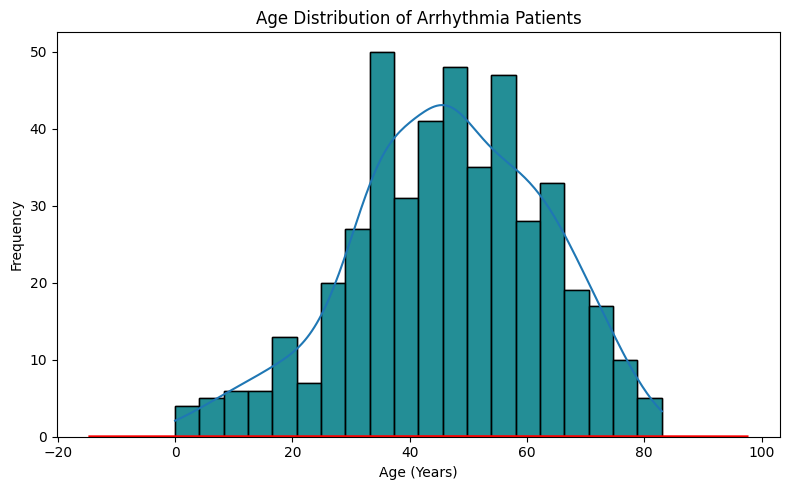

In [39]:
# age distribution plot 

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["feature_0"], bins=20, kde=True)
sns.histplot(df["feature_0"], bins=20, color="teal")
sns.kdeplot(df["feature_0"], color="red", linewidth=2)

plt.xlabel("Age (Years)")
plt.ylabel("Frequency")
plt.title("Age Distribution of Arrhythmia Patients")
plt.tight_layout()
plt.show()

In [40]:
# what are the features telling us? 

df[["feature_2", "feature_3"]].describe()

,feature_2,feature_3
count,452.000000,452.000000
mean,166.188053,68.170354
std,37.170340,16.590803
min,105.000000,6.000000
25%,160.000000,59.000000
50%,164.000000,68.000000
75%,170.000000,79.000000
max,780.000000,176.000000


In [41]:
# feature details 

df.iloc[:, 4:15].describe().T

,count,mean,std,min,25%,50%,75%,max
feature_4,452.0,88.920354,15.364394,55.0,80.00,86.0,94.00,188.0
feature_5,452.0,155.152655,44.842283,0.0,142.00,157.0,175.00,524.0
feature_6,452.0,367.207965,33.385421,232.0,350.00,367.0,384.00,509.0
feature_7,452.0,169.949115,35.633072,108.0,148.00,162.0,179.00,381.0
feature_8,452.0,90.004425,25.826643,0.0,79.00,91.0,102.00,205.0
feature_9,452.0,33.676991,45.431434,-172.0,3.75,40.0,66.00,169.0
feature_10,444.0,36.150901,57.858255,-177.0,14.00,41.0,63.25,179.0
feature_11,430.0,48.913953,29.346409,-170.0,41.00,56.0,65.00,176.0
feature_12,451.0,36.716186,36.020725,-135.0,12.00,40.0,62.00,166.0
feature_13,76.0,-13.592105,127.220248,-179.0,-124.50,-50.5,117.25,178.0


In [42]:
# structure check 
df.shape
df["diagnosis"].isna().sum()
df.duplicated().sum()

np.int64(0)